# 02. Distributed Learning

Distributed Learning is a machine learning paradigm in which computation, data, or model parameters are distributed across multiple computational workers.

As datasets and models become larger, a single machine may no longer provide sufficient memory, computational power, or training speed. Distributed learning addresses these limitations by coordinating multiple workers to perform machine learning tasks collaboratively.

This notebook covers:

- The motivation for distributed machine learning
- Distributed learning architectures
- Data parallelism
- Model parallelism
- Distributed optimization
- Synchronous and asynchronous training
- Parameter servers
- All-reduce communication
- Communication overhead
- Fault tolerance and stragglers
- Distributed hyperparameter optimization
- Local simulation of distributed training
- PyTorch Distributed Data Parallel (DDP)
- Distributed machine learning with Apache Spark
- Scalability, speedup, and parallel efficiency

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why machine learning systems need distributed computation.
2. Distinguish between data parallelism and model parallelism.
3. Understand how gradients are distributed and aggregated.
4. Explain synchronous and asynchronous distributed optimization.
5. Understand parameter-server and all-reduce architectures.
6. Analyze communication overhead and scalability.
7. Explain the straggler problem and fault tolerance.
8. Simulate distributed gradient-based learning locally.
9. Understand how PyTorch Distributed Data Parallel works.
10. Understand the role of Spark in distributed machine learning.
11. Measure speedup and parallel efficiency.
12. Identify practical limitations of distributed machine learning systems.

## 1. What Is Distributed Learning?

In conventional machine learning, a single machine performs the major stages of training:

$$
\text{Data}
\rightarrow
\text{Model}
\rightarrow
\text{Optimization}
\rightarrow
\text{Prediction}
$$

However, modern machine learning problems can involve:

- Millions or billions of training examples
- Extremely high-dimensional feature spaces
- Large neural networks
- Large language models
- Large-scale recommendation systems
- High-frequency streaming data

A single machine may become a computational or memory bottleneck.

Distributed learning addresses this problem by dividing computation across multiple workers.

A simplified distributed system can be represented as:

$$
\text{Dataset}
\rightarrow
\begin{cases}
\text{Worker}_1 \\
\text{Worker}_2 \\
\vdots \\
\text{Worker}_K
\end{cases}
\rightarrow
\text{Communication}
\rightarrow
\text{Model Update}
$$

where $K$ is the number of workers.

## 2. Why Distributed Learning?

There are several reasons to distribute machine learning computation.

### 2.1 Dataset Size

Suppose a dataset contains $N$ training examples.

If each example requires $d$ features, the storage requirement can become very large:

$$
O(Nd)
$$

For sufficiently large $N$ and $d$, the complete dataset may not fit into the memory of a single machine.

Distributed storage allows different parts of the dataset to be stored on different machines.

---

### 2.2 Computational Requirements

Suppose training requires $C$ computational operations.

A single machine must perform approximately:

$$
C
$$

operations.

With $K$ workers, the idealized computational workload per worker becomes:

$$
\frac{C}{K}
$$

Therefore, the ideal training time becomes approximately:

$$
T_K \approx \frac{T_1}{K}
$$

where:

- $T_1$ = training time with one worker
- $T_K$ = training time with $K$ workers

In practice, however, this ideal relationship is rarely achieved because workers must communicate.

---

### 2.3 Model Size

Modern models may contain billions of parameters.

If a model contains $P$ parameters and each parameter requires $b$ bytes, the parameter storage requirement is:

$$
M = Pb
$$

Large models may therefore require multiple GPUs or machines simply to store the model and its intermediate computations.

---

### 2.4 Training Speed

Distributed computation can reduce training time by performing independent computations simultaneously.

The objective is therefore not simply:

$$
\text{More Machines}
$$

but rather:

$$
\text{More Machines}
+
\text{Efficient Communication}
+
\text{Efficient Parallelization}
$$

## 3. Single-Machine vs Distributed Learning

A conventional training system might look like:

$$
\boxed{
\text{Dataset}
\rightarrow
\text{CPU/GPU}
\rightarrow
\text{Model}
\rightarrow
\text{Gradient}
\rightarrow
\text{Update}
}
$$

A distributed system instead uses multiple workers:

$$
\boxed{
\text{Dataset}
\rightarrow
\begin{cases}
W_1 \\
W_2 \\
W_3 \\
\vdots \\
W_K
\end{cases}
\rightarrow
\text{Gradient Aggregation}
\rightarrow
\text{Global Model}
}
$$

Each worker performs part of the computation.

The workers must then communicate to maintain a consistent training process.

## 4. Distributed Learning Architecture

A distributed machine learning system typically contains:

- **Workers**
- **Coordinator**
- **Communication mechanism**
- **Distributed dataset**
- **Model state**

A worker performs computation on a subset of the data.

For worker $k$, let the local dataset be:

$$
D_k
$$

The complete dataset is partitioned as:

$$
D =
\bigcup_{k=1}^{K} D_k
$$

If the partitions do not overlap:

$$
D_i \cap D_j = \emptyset
\qquad
\text{for } i \neq j
$$

The workers independently compute updates using their local data.

## Architecture Visualization

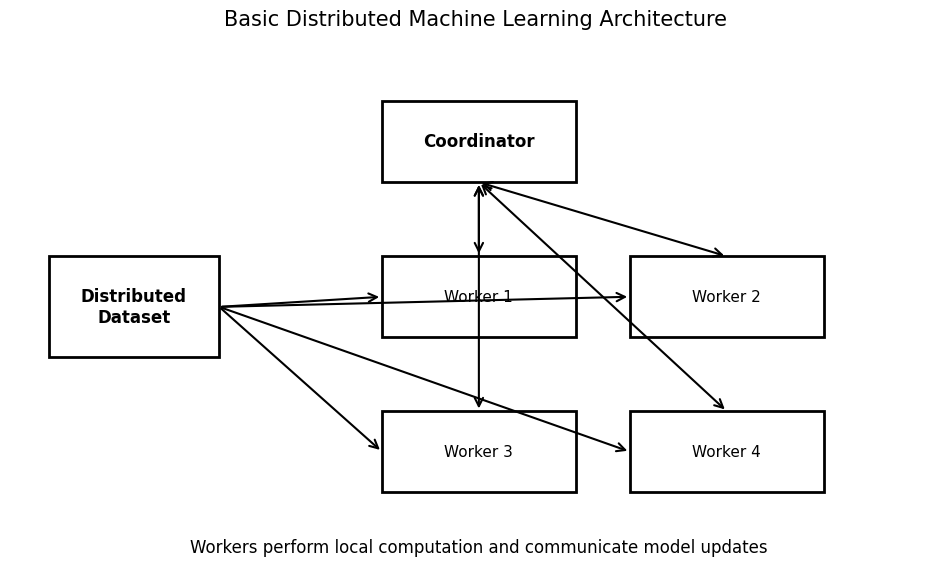

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 7))

ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis("off")

# Dataset
dataset = Rectangle((0.5, 3.2), 2.2, 1.5, fill=False, linewidth=2)
ax.add_patch(dataset)
ax.text(
    1.6, 3.95,
    "Distributed\nDataset",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# Coordinator
coord = Rectangle((4.8, 5.8), 2.5, 1.2, fill=False, linewidth=2)
ax.add_patch(coord)
ax.text(
    6.05, 6.4,
    "Coordinator",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# Workers
worker_positions = [
    (4.8, 3.5),
    (8.0, 3.5),
    (4.8, 1.2),
    (8.0, 1.2)
]

for i, (x, y) in enumerate(worker_positions, start=1):
    worker = Rectangle((x, y), 2.5, 1.2, fill=False, linewidth=2)
    ax.add_patch(worker)
    ax.text(
        x + 1.25,
        y + 0.6,
        f"Worker {i}",
        ha="center",
        va="center",
        fontsize=11
    )

# Dataset -> workers
for x, y in worker_positions:
    ax.add_patch(
        FancyArrowPatch(
            (2.7, 3.95),
            (x, y + 0.6),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.5
        )
    )

# Coordinator -> workers
for x, y in worker_positions:
    ax.add_patch(
        FancyArrowPatch(
            (6.05, 5.8),
            (x + 1.25, y + 1.2),
            arrowstyle="<->",
            mutation_scale=15,
            linewidth=1.5
        )
    )

ax.text(
    6.05,
    0.3,
    "Workers perform local computation and communicate model updates",
    ha="center",
    fontsize=12
)

plt.title("Basic Distributed Machine Learning Architecture", fontsize=15)
plt.show()

## Architecture Visualization

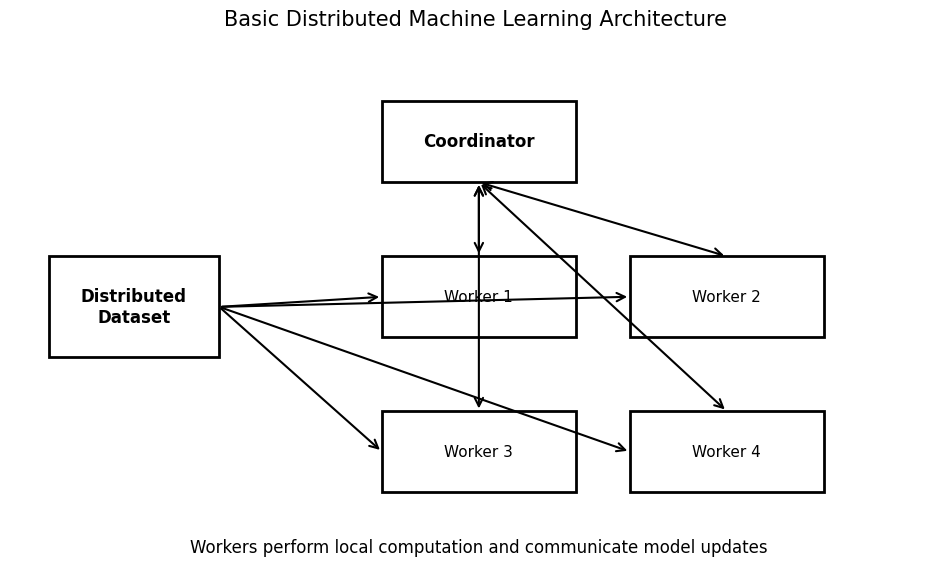

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 7))

ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis("off")

# Dataset
dataset = Rectangle((0.5, 3.2), 2.2, 1.5, fill=False, linewidth=2)
ax.add_patch(dataset)
ax.text(
    1.6, 3.95,
    "Distributed\nDataset",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# Coordinator
coord = Rectangle((4.8, 5.8), 2.5, 1.2, fill=False, linewidth=2)
ax.add_patch(coord)
ax.text(
    6.05, 6.4,
    "Coordinator",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# Workers
worker_positions = [
    (4.8, 3.5),
    (8.0, 3.5),
    (4.8, 1.2),
    (8.0, 1.2)
]

for i, (x, y) in enumerate(worker_positions, start=1):
    worker = Rectangle((x, y), 2.5, 1.2, fill=False, linewidth=2)
    ax.add_patch(worker)
    ax.text(
        x + 1.25,
        y + 0.6,
        f"Worker {i}",
        ha="center",
        va="center",
        fontsize=11
    )

# Dataset -> workers
for x, y in worker_positions:
    ax.add_patch(
        FancyArrowPatch(
            (2.7, 3.95),
            (x, y + 0.6),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.5
        )
    )

# Coordinator -> workers
for x, y in worker_positions:
    ax.add_patch(
        FancyArrowPatch(
            (6.05, 5.8),
            (x + 1.25, y + 1.2),
            arrowstyle="<->",
            mutation_scale=15,
            linewidth=1.5
        )
    )

ax.text(
    6.05,
    0.3,
    "Workers perform local computation and communicate model updates",
    ha="center",
    fontsize=12
)

plt.title("Basic Distributed Machine Learning Architecture", fontsize=15)
plt.show()

## 5. Major Forms of Distributed Parallelism

Two fundamental strategies are:

1. **Data Parallelism**
2. **Model Parallelism**

They answer different questions.

### Data Parallelism

> How can multiple machines process different parts of the dataset simultaneously?

### Model Parallelism

> How can a large model itself be divided across multiple machines?

These approaches can also be combined.

## 6. Data Parallelism

In data parallelism, every worker contains a copy of the model.

The dataset is divided among the workers.

Suppose:

$$
D = D_1 \cup D_2 \cup \cdots \cup D_K
$$

Each worker receives a different subset:

$$
D_k
$$

The model parameters are shared conceptually:

$$
\theta
$$

Each worker computes a local gradient:

$$
g_k = \nabla_\theta L(D_k, \theta)
$$

The local gradients are then aggregated.

For example, using averaging:

$$
g =
\frac{1}{K}
\sum_{k=1}^{K} g_k
$$

The global parameters are updated using:

$$
\theta_{t+1}
=
\theta_t
-
\eta g
$$

where $\eta$ is the learning rate.

## Data Parallelism Visualization

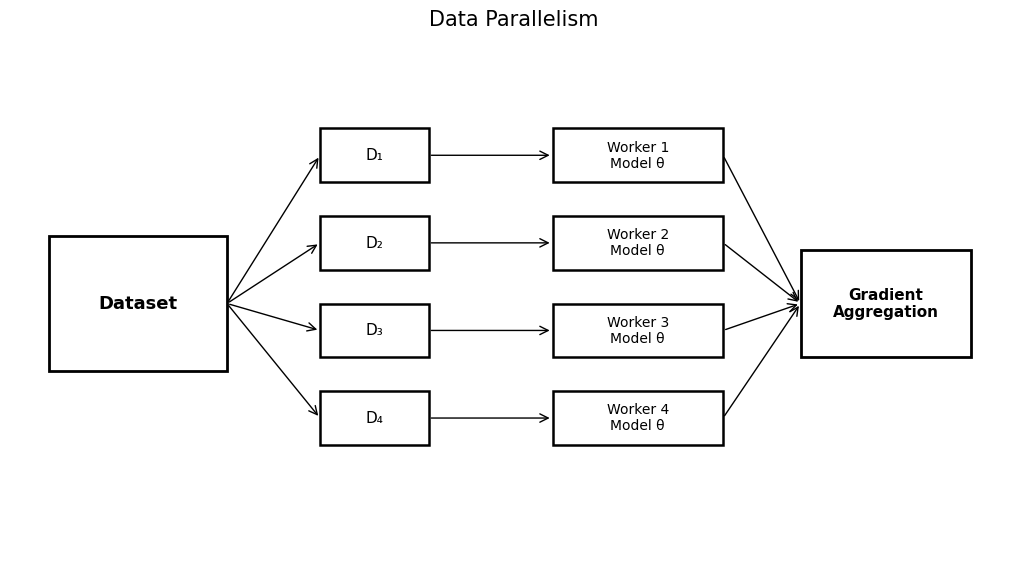

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 7))

ax.set_xlim(0, 13)
ax.set_ylim(0, 8)
ax.axis("off")

# Dataset
ax.add_patch(Rectangle((0.5, 3.0), 2.3, 2.0, fill=False, linewidth=2))
ax.text(
    1.65, 4.0,
    "Dataset",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

# Data partitions
partitions = ["D₁", "D₂", "D₃", "D₄"]

for i, label in enumerate(partitions):
    y = 5.8 - i * 1.3

    ax.add_patch(Rectangle(
        (4.0, y),
        1.4,
        0.8,
        fill=False,
        linewidth=1.8
    ))

    ax.text(
        4.7,
        y + 0.4,
        label,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.add_patch(
        FancyArrowPatch(
            (2.8, 4.0),
            (4.0, y + 0.4),
            arrowstyle="->",
            mutation_scale=15
        )
    )

# Workers
for i in range(4):
    y = 5.8 - i * 1.3

    ax.add_patch(Rectangle(
        (7.0, y),
        2.2,
        0.8,
        fill=False,
        linewidth=1.8
    ))

    ax.text(
        8.1,
        y + 0.4,
        f"Worker {i + 1}\nModel θ",
        ha="center",
        va="center",
        fontsize=10
    )

    ax.add_patch(
        FancyArrowPatch(
            (5.4, y + 0.4),
            (7.0, y + 0.4),
            arrowstyle="->",
            mutation_scale=15
        )
    )

# Aggregator
ax.add_patch(Rectangle(
    (10.2, 3.2),
    2.2,
    1.6,
    fill=False,
    linewidth=2
))

ax.text(
    11.3,
    4.0,
    "Gradient\nAggregation",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold"
)

for i in range(4):
    y = 6.2 - i * 1.3

    ax.add_patch(
        FancyArrowPatch(
            (9.2, y),
            (10.2, 4.0),
            arrowstyle="->",
            mutation_scale=15
        )
    )

plt.title("Data Parallelism", fontsize=15)
plt.show()

## 7. Model Parallelism

In model parallelism, the model itself is divided across multiple workers.

Suppose a model contains layers:

$$
f(x)
=
f_L(
f_{L-1}(
\cdots
f_2(
f_1(x)
)
\cdots
)
)
$$

The model can be partitioned:

$$
\text{Worker}_1:
f_1, f_2
$$

$$
\text{Worker}_2:
f_3, f_4
$$

$$
\text{Worker}_3:
f_5, f_6
$$

The intermediate representation must be communicated between workers.

Therefore:

$$
x
\rightarrow
W_1
\rightarrow
W_2
\rightarrow
W_3
\rightarrow
\hat{y}
$$

Model parallelism is particularly useful when the model is too large to fit on a single device.

## 8. Data Parallelism vs Model Parallelism

| Property | Data Parallelism | Model Parallelism |
|---|---|---|
| Model copy | Each worker has the model | Model is partitioned |
| Dataset | Partitioned | Can be shared |
| Main objective | Increase throughput | Fit large models |
| Communication | Gradients / parameters | Intermediate activations |
| Implementation | Generally simpler | More complex |
| Typical use | Large datasets | Very large models |

A simplified rule is:

$$
\boxed{
\text{Large Dataset}
\Rightarrow
\text{Data Parallelism}
}
$$

and

$$
\boxed{
\text{Large Model}
\Rightarrow
\text{Model Parallelism}
}
$$

Modern systems frequently combine both strategies.

## 10. Synchronous Distributed Training

In synchronous training, all workers calculate their local gradients before the global update occurs.

The process is:

$$
\theta_t
\rightarrow
\begin{cases}
g_1 \\
g_2 \\
\vdots \\
g_K
\end{cases}
\rightarrow
\text{Aggregation}
\rightarrow
\theta_{t+1}
$$

Every worker must generally wait for the other workers.

### Advantage

The optimization process is easier to reason about because the update is based on a well-defined set of gradients.

### Disadvantage

The slowest worker can delay the entire training step.

This leads to the **straggler problem**.

## 11. Asynchronous Distributed Training

In asynchronous training, workers do not necessarily wait for every other worker.

A worker can send an update as soon as it finishes its computation.

Conceptually:

$$
W_1 \rightarrow \theta
$$

$$
W_2 \rightarrow \theta
$$

$$
W_3 \rightarrow \theta
$$

at different times.

This can improve hardware utilization.

However, workers may compute gradients using stale parameters.

Suppose worker $k$ uses:

$$
\theta_{t-\tau}
$$

instead of the latest:

$$
\theta_t
$$

where $\tau$ is the staleness.

The resulting gradient may therefore be based on outdated model information.

This creates a trade-off:

$$
\boxed{
\text{Less Waiting}
\quad \leftrightarrow \quad
\text{More Stale Updates}
}
$$

## 12. Parameter Server Architecture

A parameter-server architecture separates model storage from worker computation.

The parameter server maintains:

$$
\theta
$$

Workers:

1. Receive model parameters.
2. Compute local gradients.
3. Send gradients back.
4. Receive updated parameters.

A simplified process is:

$$
\theta
\rightarrow
\text{Workers}
\rightarrow
g_1,g_2,\ldots,g_K
\rightarrow
\text{Parameter Server}
\rightarrow
\theta'
$$

The parameter server can become a communication bottleneck when the number of workers becomes large.

## 13. All-Reduce

All-reduce is another important distributed communication strategy.

Instead of sending all gradients to a central parameter server, workers collectively compute a reduction such as:

$$
g =
\frac{1}{K}
\sum_{k=1}^{K}g_k
$$

The resulting gradient is made available to every worker.

Conceptually:

$$
\begin{aligned}
W_1 &: g_1 \\
W_2 &: g_2 \\
W_3 &: g_3 \\
W_4 &: g_4
\end{aligned}
$$

becomes:

$$
\begin{aligned}
W_1 &: g \\
W_2 &: g \\
W_3 &: g \\
W_4 &: g
\end{aligned}
$$

where:

$$
g =
\frac{g_1+g_2+g_3+g_4}{4}
$$

Modern distributed deep-learning frameworks commonly use highly optimized collective communication mechanisms such as all-reduce.

## 14. Communication Cost

Distributed computation introduces a new cost:

$$
\text{Communication}
$$

The total training time can be viewed approximately as:

$$
T_{\text{total}}
=
T_{\text{computation}}
+
T_{\text{communication}}
+
T_{\text{synchronization}}
$$

Increasing the number of workers reduces computation per worker but can increase communication overhead.

Therefore:

$$
T_K
\neq
\frac{T_1}{K}
$$

in real systems.

A useful conceptual model is:

$$
T_K
=
\frac{T_{\text{compute}}}{K}
+
T_{\text{communication}}
+
T_{\text{overhead}}
$$

This explains why adding more machines eventually produces diminishing returns.

## 15. Speedup

Speedup measures how much faster a distributed system is compared with a single-worker system.

It is defined as:

$$
S_K
=
\frac{T_1}{T_K}
$$

where:

- $T_1$ = single-worker training time
- $T_K$ = training time using $K$ workers

Ideal speedup is:

$$
S_K = K
$$

For example, with four workers:

$$
S_4^{ideal}=4
$$

If the actual speedup is only $3$, communication and synchronization have reduced scalability.

## 16. Parallel Efficiency

Parallel efficiency measures how effectively the workers are being utilized.

It is defined as:

$$
E_K
=
\frac{S_K}{K}
$$

where:

$$
S_K=\frac{T_1}{T_K}
$$

Therefore:

$$
E_K
=
\frac{T_1}{K T_K}
$$

Ideal efficiency is:

$$
E_K=1
$$

or:

$$
100\%
$$

For example, if four workers achieve a speedup of $3.2$:

$$
E_4
=
\frac{3.2}{4}
=
0.8
$$

Therefore:

$$
E_4=80\%
$$

## Speedup Visualization

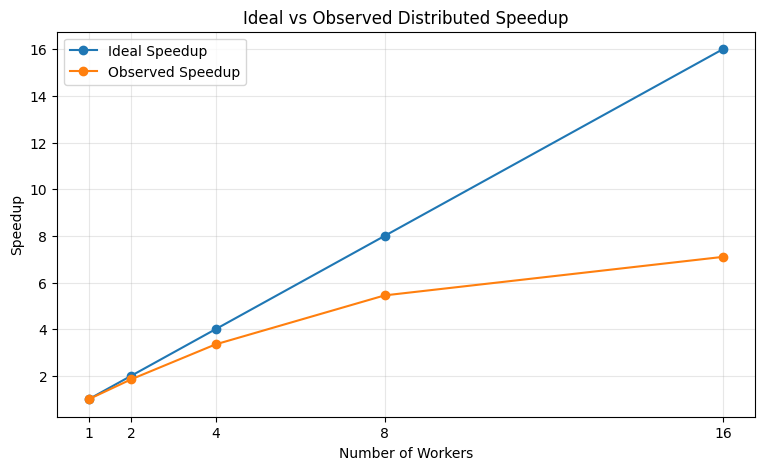

In [6]:
import numpy as np
import matplotlib.pyplot as plt

workers = np.array([1, 2, 4, 8, 16])

ideal_speedup = workers

actual_speedup = np.array([
    1.0,
    1.85,
    3.35,
    5.45,
    7.10
])

plt.figure(figsize=(9, 5))

plt.plot(
    workers,
    ideal_speedup,
    marker="o",
    label="Ideal Speedup"
)

plt.plot(
    workers,
    actual_speedup,
    marker="o",
    label="Observed Speedup"
)

plt.xlabel("Number of Workers")
plt.ylabel("Speedup")
plt.title("Ideal vs Observed Distributed Speedup")
plt.xticks(workers)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Parallel Efficiency Visualization

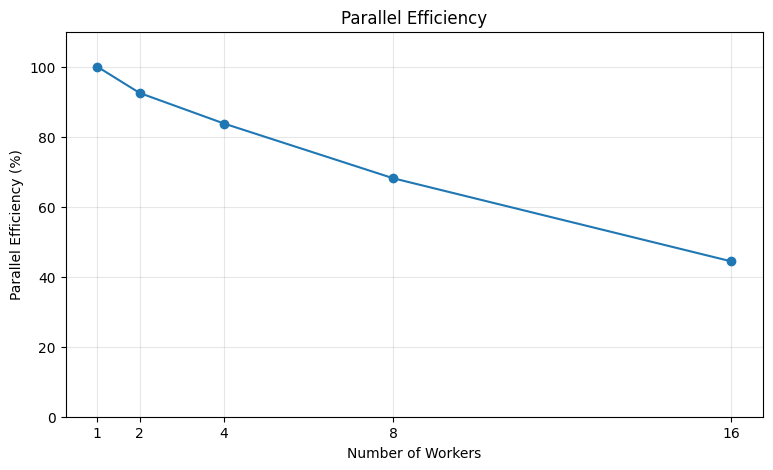

In [7]:
efficiency = actual_speedup / workers

plt.figure(figsize=(9, 5))

plt.plot(
    workers,
    efficiency * 100,
    marker="o"
)

plt.xlabel("Number of Workers")
plt.ylabel("Parallel Efficiency (%)")
plt.title("Parallel Efficiency")
plt.xticks(workers)
plt.ylim(0, 110)
plt.grid(alpha=0.3)

plt.show()

## 17. The Straggler Problem

In synchronous distributed learning, the training step often cannot continue until all workers finish.

Suppose the worker completion times are:

$$
T_1,T_2,\ldots,T_K
$$

The synchronization time is approximately determined by:

$$
T_{\text{step}}
\approx
\max(T_1,T_2,\ldots,T_K)
$$

Therefore, one slow worker can delay the entire system.

Possible causes include:

- Hardware differences
- Network congestion
- Uneven data partitions
- CPU/GPU contention
- Memory pressure
- Temporary system failures

This is known as the **straggler problem**.

## Straggler Visualization

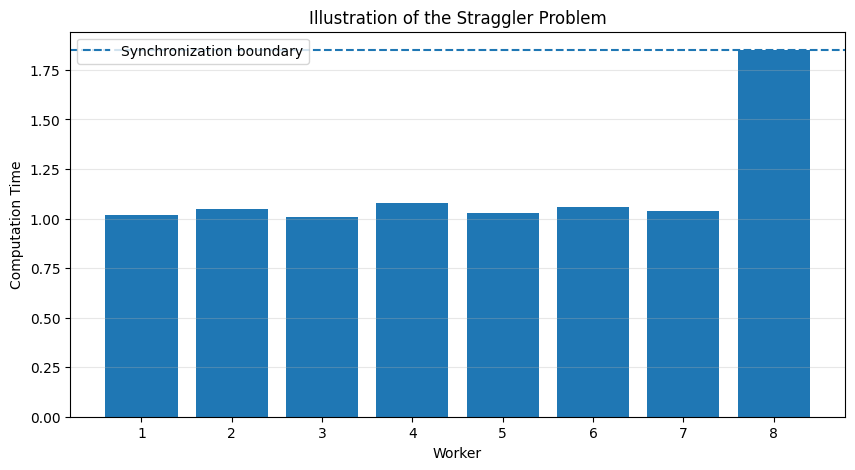

In [8]:
import numpy as np
import matplotlib.pyplot as plt

workers = np.arange(1, 9)

times = np.array([
    1.02,
    1.05,
    1.01,
    1.08,
    1.03,
    1.06,
    1.04,
    1.85
])

plt.figure(figsize=(10, 5))

plt.bar(workers, times)

plt.axhline(
    times.max(),
    linestyle="--",
    label="Synchronization boundary"
)

plt.xlabel("Worker")
plt.ylabel("Computation Time")
plt.title("Illustration of the Straggler Problem")
plt.xticks(workers)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## 18. Local Simulation of Distributed Learning

We can simulate multiple workers on a single machine.

The goal is to demonstrate the fundamental idea behind distributed gradient descent.

We will:

1. Generate a regression dataset.
2. Split the dataset among workers.
3. Give every worker the same model parameters.
4. Compute a local gradient.
5. Aggregate the gradients.
6. Update the global parameters.
7. Compare distributed training with ordinary gradient descent.

This simulation does not create actual machines.

Instead, it reproduces the mathematical behavior of distributed data parallelism.

## Generate Data

In [9]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_samples = 4000

X = rng.normal(size=(n_samples, 2))

true_weights = np.array([3.5, -2.0])
true_bias = 1.5

noise = rng.normal(0, 0.5, size=n_samples)

y = X @ true_weights + true_bias + noise

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4000, 2)
y shape: (4000,)


## Visualize the Dataset

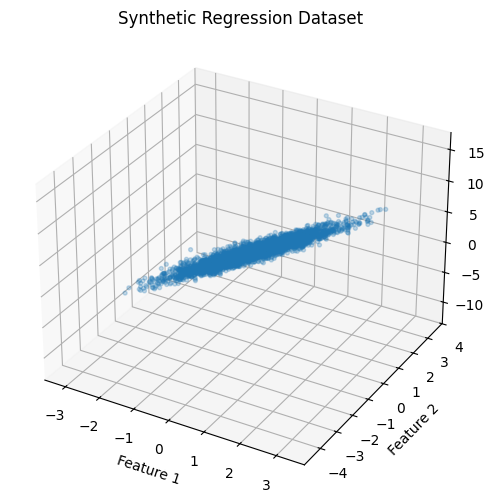

In [10]:
fig = plt.figure(figsize=(9, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X[:, 0],
    X[:, 1],
    y,
    alpha=0.25,
    s=8
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Target")

ax.set_title("Synthetic Regression Dataset")

plt.show()

## Split Data Among Workers

In [11]:
n_workers = 4

indices = np.arange(n_samples)
worker_indices = np.array_split(indices, n_workers)

for i, idx in enumerate(worker_indices, start=1):
    print(
        f"Worker {i}: "
        f"{len(idx)} samples"
    )

Worker 1: 1000 samples
Worker 2: 1000 samples
Worker 3: 1000 samples
Worker 4: 1000 samples


## 19. Local Gradient Computation

For linear regression:

$$
\hat{y}=Xw+b
$$

The mean squared error is:

$$
L(w,b)
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

The gradients are:

$$
\frac{\partial L}{\partial w}
=
-\frac{2}{n}
X^T(y-\hat{y})
$$

and:

$$
\frac{\partial L}{\partial b}
=
-\frac{2}{n}
\sum_{i=1}^{n}(y_i-\hat{y}_i)
$$

In [12]:
def compute_gradient(X_local, y_local, weights, bias):
    predictions = X_local @ weights + bias
    errors = predictions - y_local

    grad_weights = (2 / len(X_local)) * X_local.T @ errors
    grad_bias = 2 * np.mean(errors)

    loss = np.mean(errors ** 2)

    return grad_weights, grad_bias, loss

## Distributed Gradient Aggregation

In [13]:
def distributed_gradient(
    X,
    y,
    worker_indices,
    weights,
    bias
):
    gradients_w = []
    gradients_b = []
    losses = []

    for indices in worker_indices:
        grad_w, grad_b, loss = compute_gradient(
            X[indices],
            y[indices],
            weights,
            bias
        )

        gradients_w.append(grad_w)
        gradients_b.append(grad_b)
        losses.append(loss)

    global_grad_w = np.mean(gradients_w, axis=0)
    global_grad_b = np.mean(gradients_b)

    global_loss = np.mean(losses)

    return (
        global_grad_w,
        global_grad_b,
        global_loss
    )

## Train Distributed Model

In [14]:
weights = np.zeros(2)
bias = 0.0

learning_rate = 0.05
epochs = 100

history = []

for epoch in range(epochs):

    grad_w, grad_b, loss = distributed_gradient(
        X,
        y,
        worker_indices,
        weights,
        bias
    )

    weights -= learning_rate * grad_w
    bias -= learning_rate * grad_b

    history.append(loss)

print("Learned weights:", weights)
print("Learned bias:", bias)
print("True weights:", true_weights)
print("True bias:", true_bias)

Learned weights: [ 3.50905795 -1.9862893 ]
Learned bias: 1.4925522036203958
True weights: [ 3.5 -2. ]
True bias: 1.5


## Training Loss

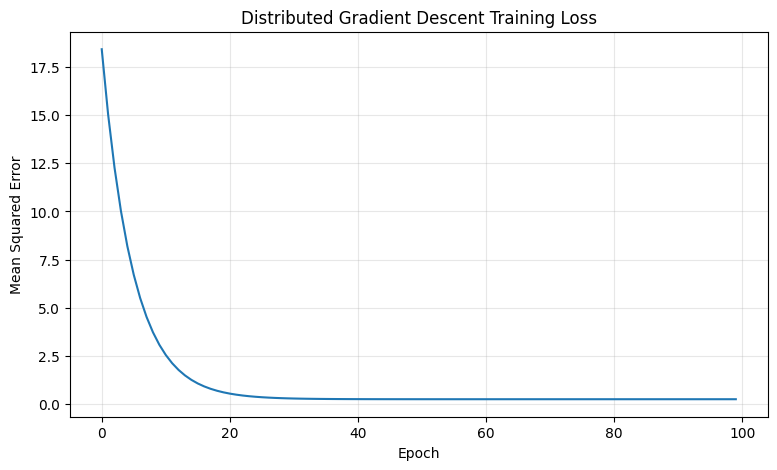

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(history)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Distributed Gradient Descent Training Loss")
plt.grid(alpha=0.3)

plt.show()

## 20. Local vs Global Gradients

At a particular optimization step, every worker produces a different gradient because each worker sees different data.

For worker $k$:

$$
g_k
=
\nabla_\theta L_k(\theta)
$$

The distributed system aggregates them:

$$
g
=
\frac{1}{K}
\sum_{k=1}^{K}g_k
$$

The important insight is that distributed learning does not require every worker to see the entire dataset.

Instead, the workers collectively approximate the gradient of the complete training objective.

In [16]:
weights = np.zeros(2)
bias = 0.0

worker_gradients = []

for indices in worker_indices:
    grad_w, grad_b, _ = compute_gradient(
        X[indices],
        y[indices],
        weights,
        bias
    )

    worker_gradients.append(grad_w)

worker_gradients = np.array(worker_gradients)

global_gradient = worker_gradients.mean(axis=0)

print("Worker gradients:")
print(worker_gradients)

print("\nGlobal averaged gradient:")
print(global_gradient)

Worker gradients:
[[-6.45571166  3.80479085]
 [-6.90812226  3.73401331]
 [-6.66645069  4.28224152]
 [-7.1593621   4.20722729]]

Global averaged gradient:
[-6.79741168  4.00706824]


## 21. Distributed Deep Learning with PyTorch

For real distributed deep-learning workloads, frameworks provide communication primitives and distributed training abstractions.

PyTorch provides:

$$
\texttt{torch.distributed}
$$

and an important high-level abstraction:

$$
\texttt{DistributedDataParallel}
$$

The basic idea is:

$$
\text{Model Replica}
+
\text{Local Data}
\rightarrow
\text{Local Gradient}
\rightarrow
\text{All-Reduce}
$$

Each process typically owns a model replica and processes its own portion of the training data.

The gradients are synchronized between workers.

### Important distinction

Our NumPy simulation demonstrates the mathematical idea.

PyTorch DDP performs actual distributed computation and communication between processes.

## 22. Minimal PyTorch DDP Example

The following code demonstrates the structure of distributed training.

It is designed to be launched using PyTorch's distributed launcher rather than executed as an ordinary notebook cell.

Each process:

1. Initializes the distributed process group.
2. Determines its worker rank.
3. Creates a model.
4. Wraps the model with `DistributedDataParallel`.
5. Loads a worker-specific portion of the dataset.
6. Performs training.

The important conceptual operation is gradient synchronization.

If worker $k$ produces:

$$
g_k
$$

the distributed system performs an operation equivalent to:

$$
g
=
\frac{1}{K}
\sum_{k=1}^{K}g_k
$$

and synchronizes the result.

## 23. Distributed Machine Learning with Apache Spark

Apache Spark is a distributed data-processing framework that can also support machine-learning workloads through MLlib.

Spark is particularly useful when the primary challenge is:

$$
\text{Large-Scale Data Processing}
$$

rather than only neural-network training.

A simplified Spark workflow is:

$$
\text{Distributed Data}
\rightarrow
\text{Feature Engineering}
\rightarrow
\text{Distributed ML}
\rightarrow
\text{Evaluation}
$$

Spark is commonly useful for:

- Large-scale feature engineering
- Distributed preprocessing
- Large tabular datasets
- ETL pipelines
- Classical machine learning
- Integration with distributed data storage

For GPU-heavy deep learning, specialized distributed training frameworks may be more appropriate.

## 24. Fault Tolerance

Distributed systems must assume that machines can fail.

A worker may experience:

- Hardware failure
- Process failure
- Network failure
- Memory exhaustion
- GPU failure

A distributed learning system therefore needs mechanisms for recovering from failures.

Possible strategies include:

### Checkpointing

Periodically save:

$$
\theta_t
$$

so training can resume after failure.

### Worker Recovery

Replace failed workers and reconstruct their state.

### Replication

Maintain redundant copies of important data or model state.

The fundamental goal is:

$$
\text{Failure}
\not\Rightarrow
\text{Complete Training Loss}
$$

## 25. Distributed Hyperparameter Optimization

Distributed computing can also be used to evaluate multiple hyperparameter configurations simultaneously.

Suppose we have:

$$
\Lambda
=
\{
\lambda_1,
\lambda_2,
\ldots,
\lambda_M
\}
$$

Instead of evaluating configurations sequentially:

$$
\lambda_1
\rightarrow
\lambda_2
\rightarrow
\cdots
\rightarrow
\lambda_M
$$

we can distribute them:

$$
\begin{cases}
W_1 \rightarrow \lambda_1 \\
W_2 \rightarrow \lambda_2 \\
W_3 \rightarrow \lambda_3 \\
\vdots \\
W_K \rightarrow \lambda_K
\end{cases}
$$

This is often called **parallel hyperparameter optimization**.

Unlike data parallelism, workers here may train completely different models.

## 26. Scalability Experiment

We can model the effect of communication overhead on distributed training.

Assume:

$$
T_1=100
$$

time units for one worker.

Suppose each worker reduces computation approximately linearly, but communication overhead increases with the number of workers.

We can construct a simple model:

$$
T_K
=
\frac{100}{K}
+
0.8\log_2(K)
$$

## 27. The Central Distributed Learning Trade-Off

Distributed learning attempts to reduce:

$$
T_{\text{computation}}
$$

by increasing the number of workers.

But it introduces:

$$
T_{\text{communication}}
$$

and:

$$
T_{\text{synchronization}}
$$

Therefore:

$$
\boxed{
\text{Distributed Training Performance}
=
\text{Computation Gains}
-
\text{Communication Costs}
}
$$

This is one of the most important ideas in distributed machine learning.

Adding more machines does not automatically produce proportional speedup.

## 29. When Should We Use Distributed Learning?

Distributed learning is useful when the workload justifies its additional complexity.

### Good candidates

- Very large datasets
- Very large models
- Long training times
- Large-scale recommendation systems
- Large language models
- Computer vision at scale
- Distributed hyperparameter search
- Large-scale data-processing pipelines

### Poor candidates

For a small dataset and a small model, distributed training may actually make the system slower.

If:

$$
T_{\text{communication}}
>
\text{computation saved}
$$

then distributing the workload provides little or no benefit.

Therefore:

$$
\boxed{
\text{Scale only when the workload requires it}
}
$$

# 30. Summary

Distributed learning allows machine learning computation to be performed across multiple workers.

The two fundamental forms of parallelism are:

$$
\boxed{\text{Data Parallelism}}
$$

and

$$
\boxed{\text{Model Parallelism}}
$$

In data parallelism, each worker processes a different subset of the dataset while maintaining a model replica.

The local gradients are aggregated:

$$
g
=
\frac{1}{K}
\sum_{k=1}^{K}g_k
$$

and the global parameters are updated:

$$
\theta_{t+1}
=
\theta_t-\eta g
$$

Distributed systems can use:

- Parameter servers
- All-reduce
- Synchronous optimization
- Asynchronous optimization

However, distributed computation introduces:

$$
\text{Communication}
+
\text{Synchronization}
+
\text{Fault-Tolerance Costs}
$$

Therefore, the practical speedup is usually smaller than the theoretical speedup.

The most important scalability concepts are:

$$
S_K=\frac{T_1}{T_K}
$$

and:

$$
E_K=\frac{S_K}{K}
$$

where $S_K$ is speedup and $E_K$ is parallel efficiency.

The central lesson is:

$$
\boxed{
\text{Distributed Learning is not simply about adding machines.}
}
$$

It is about designing an efficient system in which computation, communication, synchronization, and data movement are balanced.